In [28]:
import numpy as np
import pandas as pd

English = np.array([
    "The weather is nice today",
    "I need water",
    "Where is the station",
    "Hello",
    "Good morning",
    "Good evening",
    "I am hungry",
    "I love you",
    "The cat is sleeping",
    "Learning AI is fun"
])

German = np.array([
    "Das Wetter ist heute schön",
    "Ich brauche Wasser",
    "Wo ist der Bahnhof",
    "Hallo",
    "Guten Morgen",
    "Guten Abend",
    "Ich habe Hunger",
    "Ich liebe dich",
    "Die Katze schläft",
    "KI zu lernen macht Spaß"
])

df = pd.DataFrame({
    "English": English,
    "German": German
})

print(df)

                     English                      German
0  The weather is nice today  Das Wetter ist heute schön
1               I need water          Ich brauche Wasser
2       Where is the station          Wo ist der Bahnhof
3                      Hello                       Hallo
4               Good morning                Guten Morgen
5               Good evening                 Guten Abend
6                I am hungry             Ich habe Hunger
7                 I love you              Ich liebe dich
8        The cat is sleeping           Die Katze schläft
9         Learning AI is fun     KI zu lernen macht Spaß


In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_english=Tokenizer()
tokenizer_German=Tokenizer()

In [30]:
tokenizer_German.fit_on_texts(German)
tokenizer_english.fit_on_texts(English)

In [31]:
sequences_german = tokenizer_German.texts_to_sequences(German)
sequences_english = tokenizer_english.texts_to_sequences(English)

In [32]:
print("work Index:")
print(tokenizer_english.word_index)
print("\n")
print(tokenizer_German.word_index)

work Index:
{'is': 1, 'the': 2, 'i': 3, 'good': 4, 'weather': 5, 'nice': 6, 'today': 7, 'need': 8, 'water': 9, 'where': 10, 'station': 11, 'hello': 12, 'morning': 13, 'evening': 14, 'am': 15, 'hungry': 16, 'love': 17, 'you': 18, 'cat': 19, 'sleeping': 20, 'learning': 21, 'ai': 22, 'fun': 23}


{'ich': 1, 'ist': 2, 'guten': 3, 'das': 4, 'wetter': 5, 'heute': 6, 'schön': 7, 'brauche': 8, 'wasser': 9, 'wo': 10, 'der': 11, 'bahnhof': 12, 'hallo': 13, 'morgen': 14, 'abend': 15, 'habe': 16, 'hunger': 17, 'liebe': 18, 'dich': 19, 'die': 20, 'katze': 21, 'schläft': 22, 'ki': 23, 'zu': 24, 'lernen': 25, 'macht': 26, 'spaß': 27}


In [33]:
print("\n sequence")
print(sequences_german)
print("\n")
print(sequences_english)


 sequence
[[4, 5, 2, 6, 7], [1, 8, 9], [10, 2, 11, 12], [13], [3, 14], [3, 15], [1, 16, 17], [1, 18, 19], [20, 21, 22], [23, 24, 25, 26, 27]]


[[2, 5, 1, 6, 7], [3, 8, 9], [10, 1, 2, 11], [12], [4, 13], [4, 14], [3, 15, 16], [3, 17, 18], [2, 19, 1, 20], [21, 22, 1, 23]]


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length=11

X=pad_sequences(
    sequences_german,
    maxlen=max_length,
    padding="post"
)

print("\npadded squences of german")
X





padded squences of german


array([[ 4,  5,  2,  6,  7,  0,  0,  0,  0,  0,  0],
       [ 1,  8,  9,  0,  0,  0,  0,  0,  0,  0,  0],
       [10,  2, 11, 12,  0,  0,  0,  0,  0,  0,  0],
       [13,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 14,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1, 16, 17,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1, 18, 19,  0,  0,  0,  0,  0,  0,  0,  0],
       [20, 21, 22,  0,  0,  0,  0,  0,  0,  0,  0],
       [23, 24, 25, 26, 27,  0,  0,  0,  0,  0,  0]])

In [37]:
y=pad_sequences(
    sequences_english,
    maxlen=max_length,
    padding="post"
)
print("\npadded squences of english")
y


padded squences of english


array([[ 2,  5,  1,  6,  7,  0,  0,  0,  0,  0,  0],
       [ 3,  8,  9,  0,  0,  0,  0,  0,  0,  0,  0],
       [10,  1,  2, 11,  0,  0,  0,  0,  0,  0,  0],
       [12,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4, 14,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 15, 16,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 17, 18,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2, 19,  1, 20,  0,  0,  0,  0,  0,  0,  0],
       [21, 22,  1, 23,  0,  0,  0,  0,  0,  0,  0]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

vocab_size_german  = len(tokenizer_German.word_index) + 1   
vocab_size_english = len(tokenizer_english.word_index) + 1 

vocab_size_german

28

In [41]:
vocab_size_english

24

In [49]:
model = Sequential([
    Embedding(input_dim=vocab_size_german, output_dim=32, input_length=max_length),
    SimpleRNN(64, return_sequences=True),
    Dense(vocab_size_english, activation="softmax")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
model.fit(
    X, y,
    epochs=200,
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0000e+00 - loss: 3.1888
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.1091 - loss: 3.1149
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5182 - loss: 3.0386
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6182 - loss: 2.9531
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7182 - loss: 2.8542
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7273 - loss: 2.7397
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7273 - loss: 2.6097
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7273 - loss: 2.4660
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7182 - loss: 2.3125
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7182 - loss: 2.1542
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7182 - loss: 1.9971
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy

In [57]:
def translate(german_sentence):
    seq = tokenizer_German.texts_to_sequences([german_sentence])
    padded = pad_sequences(seq, maxlen=max_length, padding="post")
    prediction = model.predict(padded)
    predicted_ids = np.argmax(prediction, axis=-1)
    
    # Convert IDs back to words
    reverse_index = {v: k for k, v in tokenizer_english.word_index.items()}
    words = [reverse_index.get(i, "") for i in predicted_ids[0] if i != 0]
    return " ".join(words)

print(translate("morgen"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
morning


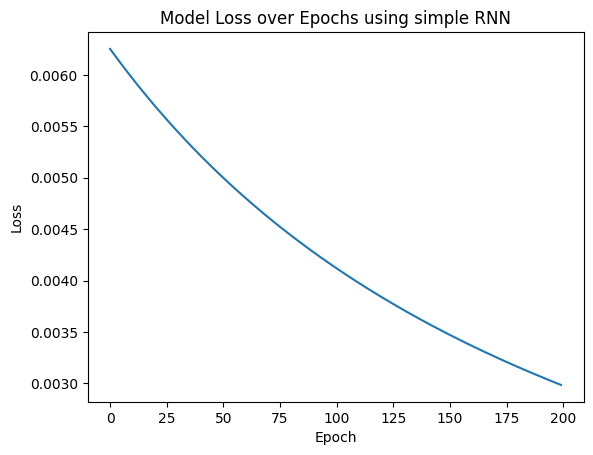

In [65]:
history = model.fit(X, y, epochs=200, verbose=0)

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.title('Model Loss over Epochs using simple RNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Using LSTM


In [58]:
model = Sequential([
    Embedding(input_dim=vocab_size_german, output_dim=32, input_length=max_length),
    LSTM(64, return_sequences=True),
    Dense(vocab_size_english, activation="softmax")
])

model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [60]:
model.fit(
    X, y,
    epochs=200,
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0182 - loss: 3.1867
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6545 - loss: 3.1637
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7364 - loss: 3.1407
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7182 - loss: 3.1165
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7182 - loss: 3.0901
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7182 - loss: 3.0606
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7182 - loss: 3.0273
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7182 - loss: 2.9891
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7182 - loss: 2.9452
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7182 - loss: 2.8944
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7182 - loss: 2.8355
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.71

In [61]:
def translate(german_sentence):
    seq = tokenizer_German.texts_to_sequences([german_sentence])
    padded = pad_sequences(seq, maxlen=max_length, padding="post")
    prediction = model.predict(padded)
    predicted_ids = np.argmax(prediction, axis=-1)
    
    # Convert IDs back to words
    reverse_index = {v: k for k, v in tokenizer_english.word_index.items()}
    words = [reverse_index.get(i, "") for i in predicted_ids[0] if i != 0]
    return " ".join(words)

print(translate("morgen"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step



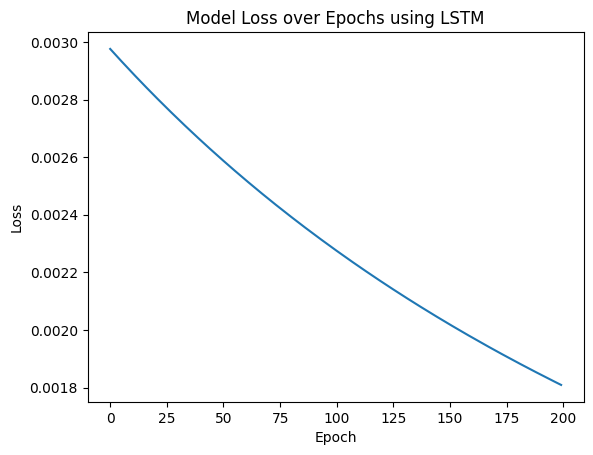

In [66]:
history1 = model.fit(X, y, epochs=200, verbose=0)

import matplotlib.pyplot as plt
plt.plot(history1.history['loss'])
plt.title('Model Loss over Epochs using LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()